# Boosting (EDA-11)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
import joblib

## Import data

In [2]:
# Reading data
X_train = pd.read_csv('../../data/processed/X_train_eda11.csv')
X_test = pd.read_csv('../../data/processed/X_test_eda11.csv')
y_train = pd.read_csv('../../data/processed/y_train_eda11.csv')
y_test = pd.read_csv('../../data/processed/y_test_eda11.csv')

## Creating model and training data - XGBoost

In [3]:
# Initialize XGBoost model
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, 
                          subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=42, n_jobs=-1)

# Train the model
xgb_model.fit(X_train, y_train.values.ravel())

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Predictions

In [4]:
# Make predictions on the test set
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

In [5]:
# Evaluate accuracy and other metrics
model_accuracy = accuracy_score(y_test, y_pred)
model_precision = precision_score(y_test, y_pred)
model_recall = recall_score(y_test, y_pred)
model_f1 = f1_score(y_test, y_pred)
model_roc_auc = roc_auc_score(y_test, y_proba)
model_cm = confusion_matrix(y_test, y_pred)
model_report = classification_report(y_test, y_pred)

In [6]:
# Showing results
model_accuracy, model_precision, model_recall, model_f1, model_roc_auc

(0.6238911821535219,
 0.570957095709571,
 0.04987171725907348,
 0.09173095787269016,
 0.5564698345327909)

In [7]:
# Showing classification report
report_dict = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
df_report

,precision,recall,f1-score,support
0.0,0.625713,0.976950,0.762843,56399.000000
1.0,0.570957,0.049872,0.091731,34689.000000
accuracy,0.623891,0.623891,0.623891,0.623891
macro avg,0.598335,0.513411,0.427287,91088.000000
weighted avg,0.604860,0.623891,0.507264,91088.000000


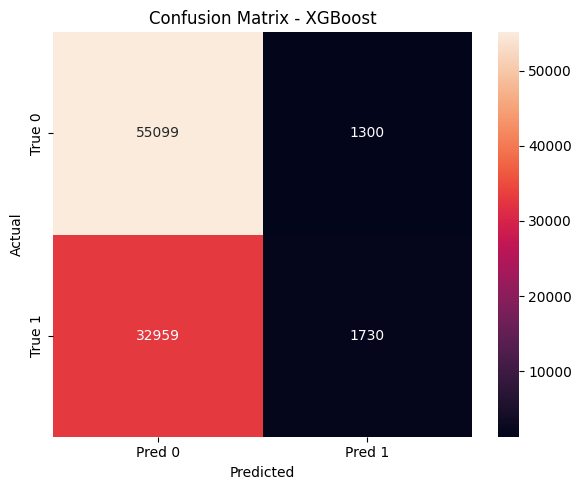

In [8]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(model_cm, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')

plt.tight_layout()
plt.show()

## Optimization

In [9]:
# Hyperparameters to test
hyperparams = {'n_estimators' : [100, 200],
               'learning_rate' : [0.05, 0.1],
               'max_depth' : [2, 3, 4],
               'min_split_loss' : [0, 0.1],
               'subsample' : [0.7, 0.8],
               'colsample_bytree' : [0.7, 0.8]}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search = GridSearchCV(xgb_model, hyperparams, scoring='roc_auc', cv=tscv, n_jobs=-1)
grid_search.fit(X_train, y_train.values.ravel())

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.7, 0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'min_split_loss': [0, 0.1], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [10]:
# Best parameters and evaluation
grid_model_xgb = grid_search.best_estimator_

y_pred_opt = grid_model_xgb.predict(X_test)
y_proba_opt = grid_model_xgb.predict_proba(X_test)[:,1]

In [11]:
# Metrics for optimized model
test_accuracy = accuracy_score(y_test, y_pred_opt)
test_precision = precision_score(y_test, y_pred_opt)
test_recall = recall_score(y_test, y_pred_opt)
test_f1 = f1_score(y_test, y_pred_opt)
test_roc_auc = roc_auc_score(y_test, y_proba_opt)

In [12]:
# Showing results
test_accuracy, test_precision, test_recall, test_f1, test_roc_auc

(0.6240668364658353,
 0.5674531155474895,
 0.05408054426475251,
 0.09874983550467167,
 0.556173586771509)

In [13]:
# Showing classification report
report_dict2 = classification_report(y_test, y_pred_opt, output_dict=True)
df_report2 = pd.DataFrame(report_dict2).transpose()
df_report2

,precision,recall,f1-score,support
0.0,0.626199,0.974645,0.762500,56399.000000
1.0,0.567453,0.054081,0.098750,34689.000000
accuracy,0.624067,0.624067,0.624067,0.624067
macro avg,0.596826,0.514363,0.430625,91088.000000
weighted avg,0.603827,0.624067,0.509724,91088.000000


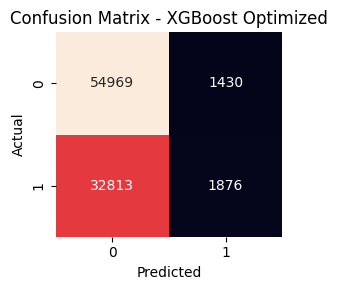

In [14]:
# Plotting confussion matrix
cm = confusion_matrix(y_test, y_pred_opt)
df_cm = pd.DataFrame(cm)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm, annot=True, fmt='d', cbar=False)
plt.title('Confusion Matrix - XGBoost Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Creating model and training data - Gradient Boosting

In [15]:
# Initialize Gradient Boosting model
gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, subsample=0.8, random_state=42)

# Train the model
gb_model.fit(X_train, y_train.values.ravel())

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## Predictions

In [16]:
# Make predictions on the test set
y_pred_gb = gb_model.predict(X_test)
y_proba_gb = gb_model.predict_proba(X_test)[:, 1]

In [17]:
# Evaluate accuracy and other metrics
model_accuracy_gb = accuracy_score(y_test, y_pred_gb)
model_precision_gb = precision_score(y_test, y_pred_gb)
model_recall_gb = recall_score(y_test, y_pred_gb)
model_f1_gb = f1_score(y_test, y_pred_gb)
model_roc_auc_gb = roc_auc_score(y_test, y_proba_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

In [18]:
# Showing results
model_accuracy_gb, model_precision_gb, model_recall_gb, model_f1_gb, model_roc_auc_gb

(0.6233093272439838,
 0.5704146432573777,
 0.044019718066245786,
 0.08173205587967672,
 0.5569679249499191)

In [19]:
# Showing classification report
report_dict3 = classification_report(y_test, y_pred_gb, output_dict=True)
df_report3 = pd.DataFrame(report_dict3).transpose()
df_report3

,precision,recall,f1-score,support
0.0,0.624911,0.979610,0.763055,56399.000000
1.0,0.570415,0.044020,0.081732,34689.000000
accuracy,0.623309,0.623309,0.623309,0.623309
macro avg,0.597663,0.511815,0.422394,91088.000000
weighted avg,0.604157,0.623309,0.503587,91088.000000


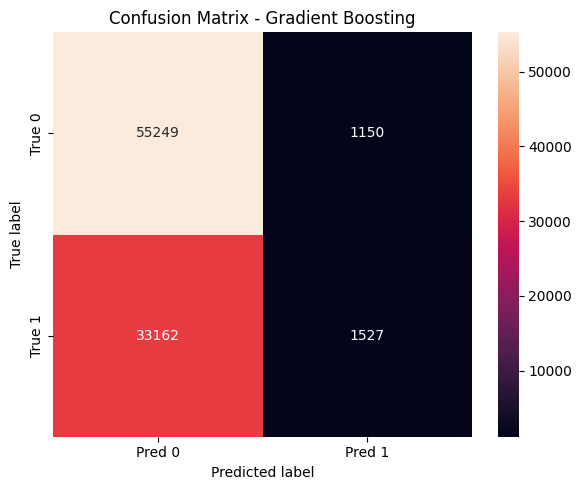

In [20]:
# Plotting confussion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])

plt.title('Confusion Matrix - Gradient Boosting')
plt.ylabel('True label')
plt.xlabel('Predicted label')

plt.tight_layout()
plt.show()

In [21]:
# Classification report
classification_report(y_test, y_pred_gb, digits=3)

'              precision    recall  f1-score   support\n\n         0.0      0.625     0.980     0.763     56399\n         1.0      0.570     0.044     0.082     34689\n\n    accuracy                          0.623     91088\n   macro avg      0.598     0.512     0.422     91088\nweighted avg      0.604     0.623     0.504     91088\n'

## Optimization

In [22]:
# Hyperparameters to test
hyperparams_gb = {'n_estimators' : [100, 200],
                  'learning_rate' : [0.05, 0.1],
                  'max_depth' : [2, 3, 4],
                  'subsample' : [0.7, 0.8],
                  'max_features' : ['sqrt', 'log2']}

# Time series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Initialize the grid search
grid_search_gb = GridSearchCV(gb_model, hyperparams_gb, scoring='roc_auc', cv=tscv, n_jobs=-1)
grid_search_gb.fit(X_train, y_train.values.ravel())

,estimator,GradientBoost...subsample=0.8)
,param_grid,"{'learning_rate': [0.05, 0.1], 'max_depth': [2, 3, ...], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200], ...}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [23]:
# Best parameters and evaluation
grid_model_gb = grid_search_gb.best_estimator_

y_pred_gb_opt = grid_model_gb.predict(X_test)
y_proba_gb_opt = grid_model_gb.predict_proba(X_test)[:,1]

In [24]:
# Metrics for optimized model
test_accuracy_gb = accuracy_score(y_test, y_pred_gb_opt)
test_precision_gb = precision_score(y_test, y_pred_gb_opt)
test_recall_gb = recall_score(y_test, y_pred_gb_opt)
test_f1_gb = f1_score(y_test, y_pred_gb_opt)
test_roc_auc_gb = roc_auc_score(y_test, y_proba_gb_opt)

In [25]:
# Showing results
test_accuracy_gb, test_precision_gb, test_recall_gb, test_f1_gb, test_roc_auc_gb

(0.6231885649042684,
 0.5547904191616766,
 0.053417509873446914,
 0.09745194456861869,
 0.555232086543392)

In [26]:
# Showing classification report
report_dict4 = classification_report(y_test, y_pred_gb_opt, output_dict=True)
df_report4 = pd.DataFrame(report_dict4).transpose()
df_report4

,precision,recall,f1-score,support
0.0,0.625792,0.973634,0.761889,56399.000000
1.0,0.554790,0.053418,0.097452,34689.000000
accuracy,0.623189,0.623189,0.623189,0.623189
macro avg,0.590291,0.513526,0.429670,91088.000000
weighted avg,0.598753,0.623189,0.508852,91088.000000


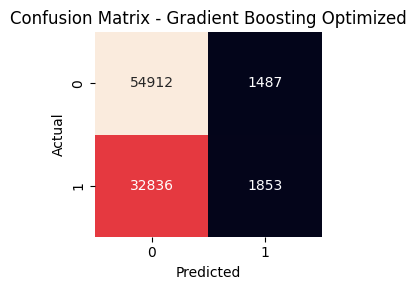

In [27]:
# Plotting confussion matrix
bank_cm4 = confusion_matrix(y_test, y_pred_gb_opt)
df_cm4 = pd.DataFrame(bank_cm4)

plt.figure(figsize=(3, 3))
sns.heatmap(df_cm4, annot=True, fmt='d', cbar=False)
plt.title('Confusion Matrix - Gradient Boosting Optimized')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

## Save model

In [28]:
# Saving best model
# joblib.dump(grid_model_gb, '../../data/models/gradient-model-final.pkl')